# TALLER PRÁCTICO – MACHINE LEARNING

## Clasificación vs Regresión (Elección del modelo)

### Objetivo del taller

Aplicar un flujo básico de Machine Learning para resolver un problema real, identificando correctamente si se trata de regresión o clasificación, construyendo un modelo predictivo y evaluando su desempeño.

---

# DATASETS

## Elije uno de los dos:

### Dataset 1: Predicción de precio de un carro

- https://www.kaggle.com/datasets/hellbuoy/car-price-prediction

**Objetivo del negocio:** estimar el precio de un vehículo basado en sus características.

### Dataset 2: Predicción de aprobación de préstamos

- https://www.kaggle.com/datasets/altruistdelhite04/loan-prediction-problem-dataset

**Objetivo del negocio:** predecir si una solicitud de crédito será aprobada o no.

---

# INSTRUCCIONES DEL TALLER

## Parte 1 – Comprensión del problema

- Identifica la variable objetivo (target).

Responde:

- ¿Es un problema de clasificación o regresión?
- ¿Por qué?
- Describe brevemente el contexto del problema.

---

## Parte 2 – Exploración de datos (EDA básica)

- Revisar valores nulos.
- Identificar variables numéricas y categóricas.
- Detectar la variable objetivo.
- Mostrar al menos:
  - 2 gráficos (ej: distribución, conteos o correlación).

---

## Parte 3 – Preparación de datos

- Manejo de valores faltantes.
- Codificación de variables categóricas.
- Separación en:
  - **X** (variables predictoras).
  - **y** (variable objetivo).
- División entrenamiento / prueba (80/20 o 70/30).

---

## Parte 4 – Modelado

- Entrenar al menos 2 modelos.

---

## Parte 5 – Evaluación del modelo

### Si es REGRESIÓN

- MAE.
- MSE.
- R².

### Si es CLASIFICACIÓN

- Accuracy.
- Precision.
- Recall.
- F1-score.
- Matriz de confusión.

---

## Parte 6 – Interpretación

Responder:

- ¿Qué tan bueno es el modelo?
- ¿Qué variable parece influir más en la predicción?
- ¿Qué mejorarías si tuvieras más tiempo?

# Desarrollo
---
> **Dataset seleccionado:** Predicción de precio de un carro (./dataset.csv)
---
## Parte 1 Comprensión del problema

In [1]:
# Imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_csv('dataset.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    str    
 3   fueltype          205 non-null    str    
 4   aspiration        205 non-null    str    
 5   doornumber        205 non-null    str    
 6   carbody           205 non-null    str    
 7   drivewheel        205 non-null    str    
 8   enginelocation    205 non-null    str    
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    str    
 15  cylindernumber    205 non-null    str    
 16  enginesize        205 non-null    int64  
 17  fuelsyst

In [3]:
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


1. La variable objetivo es *price*
2. Es un problema de regresión; ya que se busca predecir un valor numérico continuo (*price*) utilizando sus *características* (lo demás). Como no es una variable categórica, corresponde a un problema de regresión.
3. Se busca predecir el precio de un automovil basándose en sus características físicas y técnicas.
---
## Parte 2 Exploración de datos


In [4]:
# Aquí podría probar a hacer de CarName una variable categórica (esto creo que hace parte de la parte 3 pero pues ya que jajaja)
df['brand'] = df['CarName'].str.split().str[0].str.lower()
df = df.drop(columns=['CarName', 'car_ID'])
print(f"Categorías resultantes:\n{df['brand'].unique()}\n")
# Mapeo de marcas a categorías (hay algunas que están mal escritas)
brand_mapping = {
    'alfa-romeo': ['alfa-romero', 'alfa-romeo'],
    'audi': ['audi'],
    'bmw': ['bmw'],
    'chevrolet': ['chevrolet'],
    'dodge': ['dodge'],
    'honda': ['honda'],
    'isuzu': ['isuzu'],
    'jaguar': ['jaguar'],
    'mazda': ['mazda', 'maxda'],
    'buick': ['buick'],
    'mercury': ['mercury'],
    'mitsubishi': ['mitsubishi'],
    'nissan': ['nissan'],
    'peugeot': ['peugeot'],
    'plymouth': ['plymouth'],
    'porsche': ['porsche', 'porcshce'],
    'renault': ['renault'],
    'saab': ['saab'],
    'subaru': ['subaru'],
    'toyota': ['toyota', 'toyouta'],
    'volkswagen': ['volkswagen', 'vw', 'vokswagen'],
    'volvo': ['volvo']
}
df['brand'] = df['brand'].replace({v: k for k, lst in brand_mapping.items() for v in lst})
print(f"Categorías resultantes después del mapeo:\n{df['brand'].unique()}\n")

Categorías resultantes:
['alfa-romero' 'audi' 'bmw' 'chevrolet' 'dodge' 'honda' 'isuzu' 'jaguar'
 'maxda' 'mazda' 'buick' 'mercury' 'mitsubishi' 'nissan' 'peugeot'
 'plymouth' 'porsche' 'porcshce' 'renault' 'saab' 'subaru' 'toyota'
 'toyouta' 'vokswagen' 'volkswagen' 'vw' 'volvo']

Categorías resultantes después del mapeo:
['alfa-romeo' 'audi' 'bmw' 'chevrolet' 'dodge' 'honda' 'isuzu' 'jaguar'
 'mazda' 'buick' 'mercury' 'mitsubishi' 'nissan' 'peugeot' 'plymouth'
 'porsche' 'renault' 'saab' 'subaru' 'toyota' 'volkswagen' 'volvo']



In [5]:
# Nulos por columna
null_counts = df.isnull().sum()
if null_counts.any():
    print("Columnas con valores nulos:")
    print(null_counts[null_counts > 0])
else:
    print("No hay valores nulos en el DataFrame.")

No hay valores nulos en el DataFrame.


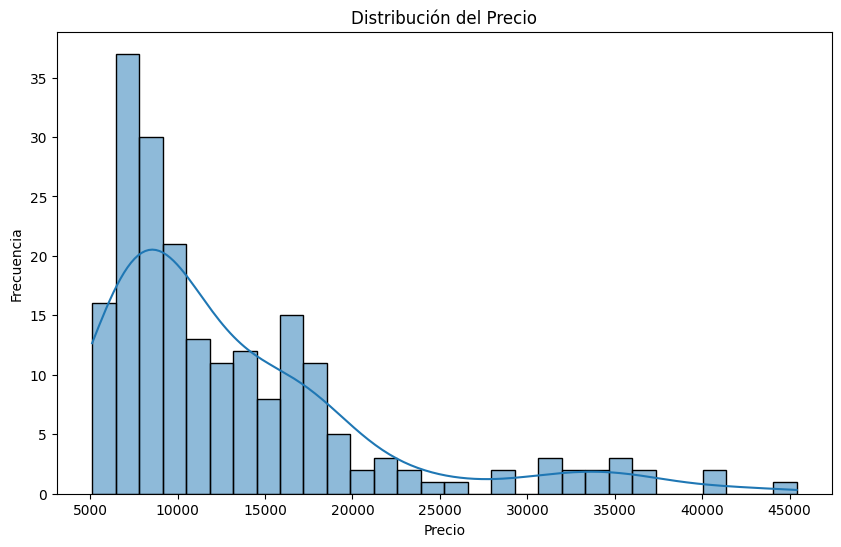

In [6]:
# La variable objetivo es 'price', la ultima columna del df, distribución:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=30, kde=True)
plt.title("Distribución del Precio")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.show()


> Es más **común** ver vehículos entre $5.000 y $10.000 USD en cuanto a rangos de precios.

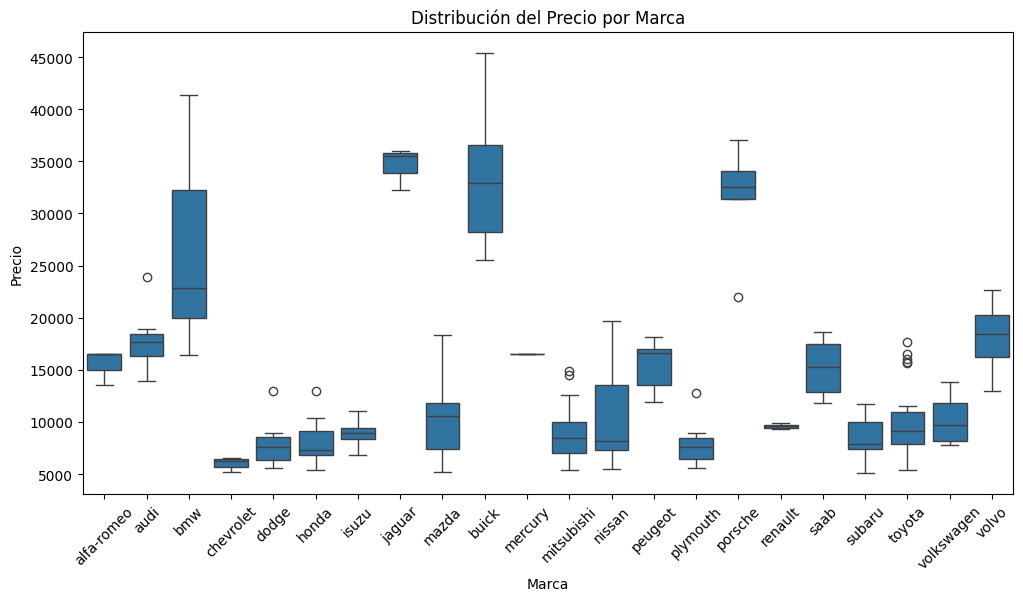

In [7]:
# Correlación entre brand y price
plt.figure(figsize=(12, 6))
sns.boxplot(x='brand', y='price', data=df)
plt.title("Distribución del Precio por Marca")
plt.xlabel("Marca")
plt.ylabel("Precio")
plt.xticks(rotation=45)
plt.show()

> Se puede apreciar que hay 4 marcas especialmente caras, el bmw, el jaguar, el buick y el porsche. Debo decir que me sorprende que alfa romeo o audi estén entre los rangos de precios medio altos.

---
## Parte 3 Preparación de los datos

In [8]:
# Para la parte 3 ya había hecho algunos arreglos antes... Como eliminar el car_ID y arreglar los nombres de las marcas
# Como no tenemos nulos entonces no hay que hacer nada con eso
# ahora codificar los dummies jejeje
# para no complicarme la vida voy a extraer los nombres de las variables categóricas y luego hacer get_dummies
categorical_columns = list(df.select_dtypes(include=['object']).columns)
df = pd.get_dummies(df, columns=categorical_columns, drop_first=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 65 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   symboling              205 non-null    int64  
 1   wheelbase              205 non-null    float64
 2   carlength              205 non-null    float64
 3   carwidth               205 non-null    float64
 4   carheight              205 non-null    float64
 5   curbweight             205 non-null    int64  
 6   enginesize             205 non-null    int64  
 7   boreratio              205 non-null    float64
 8   stroke                 205 non-null    float64
 9   compressionratio       205 non-null    float64
 10  horsepower             205 non-null    int64  
 11  peakrpm                205 non-null    int64  
 12  citympg                205 non-null    int64  
 13  highwaympg             205 non-null    int64  
 14  price                  205 non-null    float64
 15  fueltype_gas     

/tmp/ipykernel_157467/729395199.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = list(df.select_dtypes(include=['object']).columns)


In [9]:
# Variables x, y
x = df.drop(columns=['price'])
y = df['price']

In [10]:
# division de entrenamiento y prueba
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [11]:
# normalización
X_train = StandardScaler().fit_transform(x_train)
X_test = StandardScaler().fit_transform(x_test)

---
## Parte 4 - Modelado

In [12]:
# Escogí Regresión Lineal y Random Forest

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [13]:
# Predicciones
y_pred_linear = linear_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

---
## Parte 5 Evaluación

In [14]:
# Regresión linear
print("Linear Regression:")
print(f"MAE: {mean_absolute_error(y_test, y_pred_linear)}")
print(f"MSE: {mean_squared_error(y_test, y_pred_linear)}")
print(f"R^2: {r2_score(y_test, y_pred_linear)}\n")

Linear Regression:
MAE: 2010.7637734226062
MSE: 9259849.926691692
R^2: 0.8827035939706261



In [15]:
# Random Forest
print("Random Forest Regression:")
print(f"MAE: {mean_absolute_error(y_test, y_pred_rf)}")
print(f"MSE: {mean_squared_error(y_test, y_pred_rf)}")
print(f"R^2: {r2_score(y_test, y_pred_rf)}\n")

Random Forest Regression:
MAE: 2094.683406504065
MSE: 9651152.357884664
R^2: 0.8777468863335846



In [16]:
importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)
importance.head(10)

,Feature,Importance
6,enginesize,0.544159
5,curbweight,0.298449
13,highwaympg,0.044743
10,horsepower,0.033483
3,carwidth,0.013090
2,carlength,0.007767
44,brand_bmw,0.007114
1,wheelbase,0.006991
12,citympg,0.006420
11,peakrpm,0.006174


---
## Parte 6 Interpretación

> Qué tan bueno es el modelo?
>
> Ambos obtuvieron un buen desempeño en este caso; en regresión lineal, se alcanzó un R² de 0.883 aproximadamente y random forest obtuvo 0.878. Ambos modelos explican aproximadamente el 88% de la variablilidad del precio... sin embargo, Regresión linear presentó valores ligreramente menores de MAE y MSE, lo que indica que se ajusta mejor a este conjunto de datos.
---
> Qué variable parece influir más en la predicción?
>
> Para esta pregunta tuve que hacer un calculo pequeñito aprovechando el random forest, y para este caso, enginesize parece ser más determinante en el precio.
---
> Qué mejoraría si tuviera más tiempo?
>
> En términos generales, faltaría la parte de los hiperparámetros y/o comparar otros modelos. Podría revisar variables para ver cuáles pueden ser irrelevantes y quizás así mejorar o no la capacidad predictiva del modelo.